# P2 — Congestion Heatmap & Spatial Analysis

> Feature: *"Show WHERE congestion concentrates, and how risky each corridor already is."

## What this notebook produces

| Output | File | Consumed by |
|--------|------|-------------|
| DBSCAN hotspot zones (GeoJSON) | `models/hotspot_zones.geojson` | P3 deployment engine |
| Corridor risk scores table | `models/corridor_risk_scores.json` | P3 deployment engine |
| KDE grid (numpy arrays) | `models/kde_grid.npz` | Leaflet heatmap layer via API |
| Fitted KDE object | `models/kde_model.joblib` | Live prediction endpoint |
| DBSCAN model + index | `models/dbscan_model.joblib` | Zone-lookup endpoint |
| Metadata | `models/p2_metadata.json` | API + documentation |

## Integration contracts 

**Inputs consumed from P1:**  
- `composite_impact_score` (int 1–10) — used to weight KDE intensity instead of raw count  
- `closure_probability` (float 0–1) — used as secondary weight on corridor risk

**Outputs provided to P3 (via API):**  
```json
GET /corridors/risk → [{"corridor": "Mysore Road", "risk_score": 0.82, "closure_rate": 0.11, "event_count": 743, "peak_hour": 21}]
GET /heatmap?cause=vehicle_breakdown&time_band=evening → {"type": "FeatureCollection", ...}
GET /hotspots → [{"cluster_id": 0, "centroid_lat": 13.02, "centroid_lon": 77.57, "size": 312, "risk_level": "HIGH"}]
```

## Data reality check (pre-verified against ASTraM)

- `latitude`/`longitude` — 100% populated, Bengaluru bounding box 12.80–13.27°N, 77.31–77.77°E
- `endlatitude`/`endlongitude` — only 8.4% populated (689 rows), NOT usable as primary spatial key
- `junction` — 30.7% filled — used as optional label on clusters, NOT as grouping key
- `zone` — 42% filled — same treatment
- `corridor` — 99.8% filled — the one named-field safe to rely on
- **38.2% of events are `Non-corridor`** — corridor table covers only 61.8% of incidents; the heatmap covers all of them

In [2]:
# ─── Setup ─────────────────────────────────────────────────────────────────
from pathlib import Path
import json, warnings, os
from datetime import datetime
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from scipy.stats import gaussian_kde
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MinMaxScaler
import joblib

# Try to mount Google Colab drive, fallback if running locally
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Running in Google Colab. Drive mounted successfully.")
except ImportError:
    print("Running locally. Skipping Google Drive mount.")

DATA_PATH = Path('../../data/Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv')
MODEL_DIR = Path('../models')

# ═══════════════ EDIT THIS BLOCK ═══════════════
P1_SCORES_AVAILABLE = False            # set False if P1 hasn't exported yet; we compute a fallback
RANDOM_STATE = 42
# ═══════════════════════════════════════════════

MODEL_DIR.mkdir(exist_ok=True)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
print('Setup complete.')

Running locally. Skipping Google Drive mount.
Setup complete.


## 0. Load & validate

In [3]:
# ─── Load raw data ──────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Loaded {len(df_raw):,} rows × {df_raw.shape[1]} columns')

REQUIRED_COLS = ['latitude', 'longitude', 'event_cause', 'requires_road_closure',
                 'priority', 'corridor', 'start_datetime', 'event_type',
                 'endlatitude', 'endlongitude', 'junction', 'zone', 'status']
missing = [c for c in REQUIRED_COLS if c not in df_raw.columns]
if missing:
    print(f'  Missing columns: {missing}')
else:
    print('✓ All required columns present')

Loaded 8,173 rows × 46 columns
✓ All required columns present


In [4]:
# ─── Clean & enrich ─────────────────────────────────────────────────────────
df = df_raw.copy()

# Parse datetimes
df['_start_dt'] = pd.to_datetime(df['start_datetime'], errors='coerce', utc=True).dt.tz_localize(None)
df['hour']  = df['_start_dt'].dt.hour.fillna(12).astype(int)
df['dow']   = df['_start_dt'].dt.dayofweek.fillna(0).astype(int)
df['month'] = df['_start_dt'].dt.month.fillna(1).astype(int)

# Coordinates — ALL rows have valid lat/lon so no filtering needed
df['lat'] = pd.to_numeric(df['latitude'],  errors='coerce')
df['lon'] = pd.to_numeric(df['longitude'], errors='coerce')
BENGALURU_BOX = dict(lat_min=12.80, lat_max=13.27, lon_min=77.31, lon_max=77.77)
coord_mask = (df['lat'].between(BENGALURU_BOX['lat_min'], BENGALURU_BOX['lat_max']) &
              df['lon'].between(BENGALURU_BOX['lon_min'], BENGALURU_BOX['lon_max']))
print(f'Rows inside Bengaluru bounding box: {coord_mask.sum():,} / {len(df):,}')
df = df[coord_mask].copy().reset_index(drop=True)

# End-coordinates — available for 8.4%; used only as event-stretch proxy (optional enrichment)
df['end_lat'] = pd.to_numeric(df['endlatitude'],  errors='coerce').replace(0.0, np.nan)
df['end_lon'] = pd.to_numeric(df['endlongitude'], errors='coerce').replace(0.0, np.nan)
df['has_end_coord'] = (df['end_lat'].notna() & df['end_lon'].notna())
print(f'Rows with end coords (event stretch info): {df["has_end_coord"].sum():,} ({df["has_end_coord"].mean()*100:.1f}%)')

# Categorical cleaning
def _clean(s, default):
    return s.fillna(default).astype(str).str.lower().str.strip().replace('', default).replace('null', default)

df['cause']     = _clean(df['event_cause'],          'unknown')
df['corridor']  = _clean(df['corridor'],              'non-corridor')
df['zone']      = _clean(df['zone'],                  'no_zone')
df['junction']  = _clean(df['junction'],              'no_junction')
df['priority']  = _clean(df['priority'],              'unknown')
df['event_type']= _clean(df['event_type'],            'unplanned')

# Binary labels
df['closure']  = df['requires_road_closure'].astype(str).str.lower().str.strip().isin(['true','yes','1']).astype(int)
df['is_high_priority'] = (df['priority'] == 'high').astype(int)

# Time bands matching real ASTraM peaks
df['time_band'] = 'off_peak'
df.loc[df['hour'].between(4, 7),   'time_band'] = 'early_morning'   # peak 1
df.loc[df['hour'].between(19, 22), 'time_band'] = 'evening'          # peak 2
df.loc[df['hour'].between(0, 3),   'time_band'] = 'late_night'

print(f'\nTime band distribution:')
print(df['time_band'].value_counts())
print(f'\nCause distribution (top 10):')
print(df['cause'].value_counts().head(10))

Rows inside Bengaluru bounding box: 8,172 / 8,173
Rows with end coords (event stretch info): 689 (8.4%)

Time band distribution:
time_band
evening          2633
early_morning    2358
off_peak         1623
late_night       1558
Name: count, dtype: int64

Cause distribution (top 10):
cause
vehicle_breakdown    4896
others                638
pot_holes             537
construction          479
water_logging         458
accident              365
tree_fall             284
road_conditions       170
congestion            136
public_event           84
Name: count, dtype: int64


## 1. P1 Impact Score integration

P2's heatmap intensity is weighted by P1's `composite_impact_score` — a 1–10 engineered score built from closure probability, priority, and duration. This means a single 8/10 incident creates more "heat" than 3 benign 2/10 events, which is operationally correct.

If P1's model files aren't ready yet, we fall back to a local proxy built from the same raw labels.

In [5]:
# ─── P1 impact score integration ────────────────────────────────────────────
P1_SCORE_PATH = MODEL_DIR / 'p1_all_scores.parquet'  # P1 exports this at the end of their notebook

if P1_SCORES_AVAILABLE and P1_SCORE_PATH.exists():
    p1_scores = pd.read_parquet(P1_SCORE_PATH)
    df = df.merge(p1_scores[['composite_impact_score', 'closure_probability']],
                  left_index=True, right_index=True, how='left')
    df['impact_weight'] = df['composite_impact_score'].fillna(5.0) / 10.0
    print(f'✓ P1 scores loaded. Mean impact: {df["composite_impact_score"].mean():.2f}')
else:
    print('   P1 scores not found — computing local proxy.')
    print('    Proxy = 0.4*priority + 0.4*closure + 0.2*(is_planned_event*0.5 + 0.5)')
    print('    Replace with real P1 scores on Day 6.')
    # Proxy: mirrors P1 weights without the duration component (not available here)
    pri_score  = df['is_high_priority'].astype(float)
    clos_score = df['closure'].astype(float)
    plan_score = (df['event_type'] == 'planned').astype(float) * 0.5 + 0.5
    raw = 0.4 * pri_score + 0.4 * clos_score + 0.2 * plan_score
    df['composite_impact_score'] = np.clip(np.round(1 + 9 * raw), 1, 10).astype(int)
    df['closure_probability']   = clos_score  # binary proxy
    df['impact_weight'] = df['composite_impact_score'] / 10.0

print(f'Impact weight distribution: min={df["impact_weight"].min():.2f}, '
      f'mean={df["impact_weight"].mean():.2f}, max={df["impact_weight"].max():.2f}')

   P1 scores not found — computing local proxy.
    Proxy = 0.4*priority + 0.4*closure + 0.2*(is_planned_event*0.5 + 0.5)
    Replace with real P1 scores on Day 6.
Impact weight distribution: min=0.20, mean=0.48, max=1.00


## 2. Temporal EDA — confirming the two real peaks

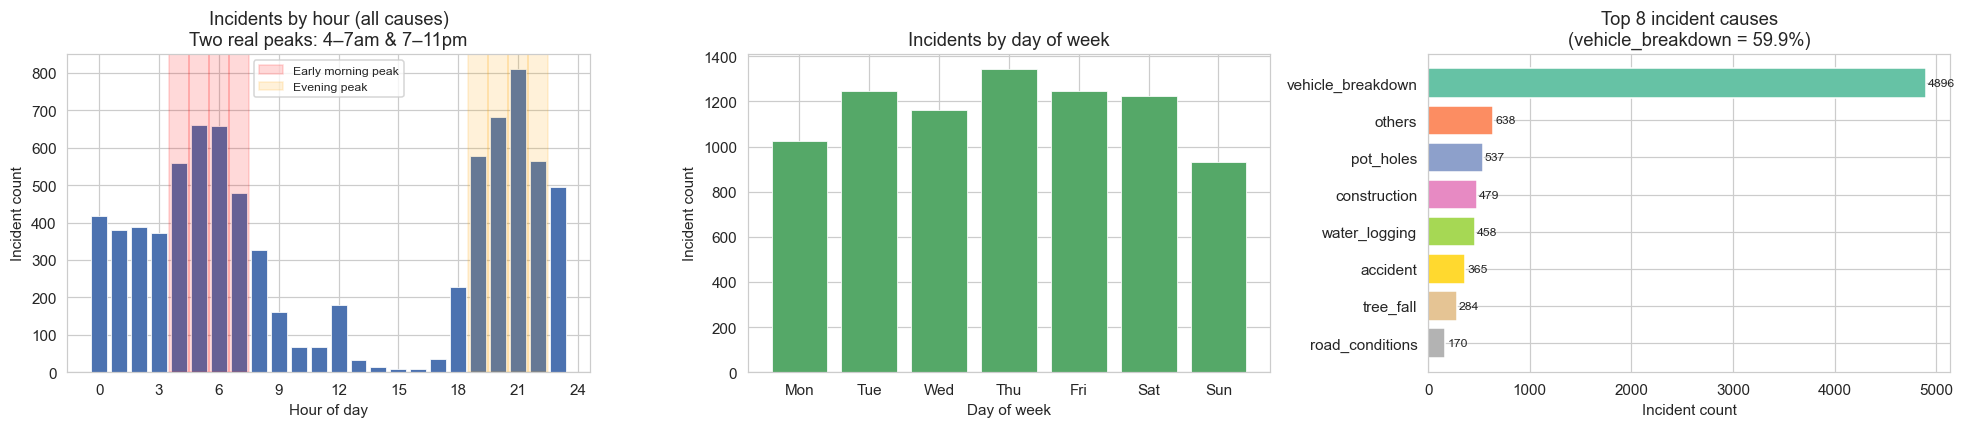

Time band breakdown:
                  n  closure_rate  mean_impact
time_band                                     
early_morning  2358         0.083        4.755
evening        2633         0.059        4.727
late_night     1558         0.063        4.798
off_peak       1623         0.140        4.869


In [6]:
# ─── Temporal analysis ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Events by hour
hourly = df.groupby('hour').size()
ax = axes[0]
bars = ax.bar(hourly.index, hourly.values, color='#4C72B0', edgecolor='white', linewidth=0.5)
# Shade the two peak windows
for h in [4, 5, 6, 7]:
    ax.axvspan(h - 0.5, h + 0.5, alpha=0.15, color='red', label='Early morning peak' if h == 4 else '')
for h in [19, 20, 21, 22]:
    ax.axvspan(h - 0.5, h + 0.5, alpha=0.15, color='orange', label='Evening peak' if h == 19 else '')
ax.set_xlabel('Hour of day'); ax.set_ylabel('Incident count')
ax.set_title('Incidents by hour (all causes)\nTwo real peaks: 4–7am & 7–11pm')
ax.legend(fontsize=8); ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# Events by day of week
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily = df.groupby('dow').size()
axes[1].bar(daily.index, daily.values, color='#55A868', edgecolor='white', linewidth=0.5)
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(dow_labels)
axes[1].set_xlabel('Day of week'); axes[1].set_ylabel('Incident count')
axes[1].set_title('Incidents by day of week')

# Events by cause (top 8)
cause_counts = df['cause'].value_counts().head(8)
colors = plt.cm.Set2(np.linspace(0, 1, len(cause_counts)))
axes[2].barh(cause_counts.index[::-1], cause_counts.values[::-1], color=colors[::-1])
axes[2].set_xlabel('Incident count')
axes[2].set_title('Top 8 incident causes\n(vehicle_breakdown = 59.9%)')
for i, (v, label) in enumerate(zip(cause_counts.values[::-1], cause_counts.index[::-1])):
    axes[2].text(v + 20, i, str(v), va='center', fontsize=8)

plt.tight_layout(); plt.show()

print(f'Time band breakdown:')
print(df.groupby('time_band').agg(
    n=('lat','count'),
    closure_rate=('closure','mean'),
    mean_impact=('composite_impact_score','mean')
).round(3))

## 3. Spatial EDA — raw coordinate scatter

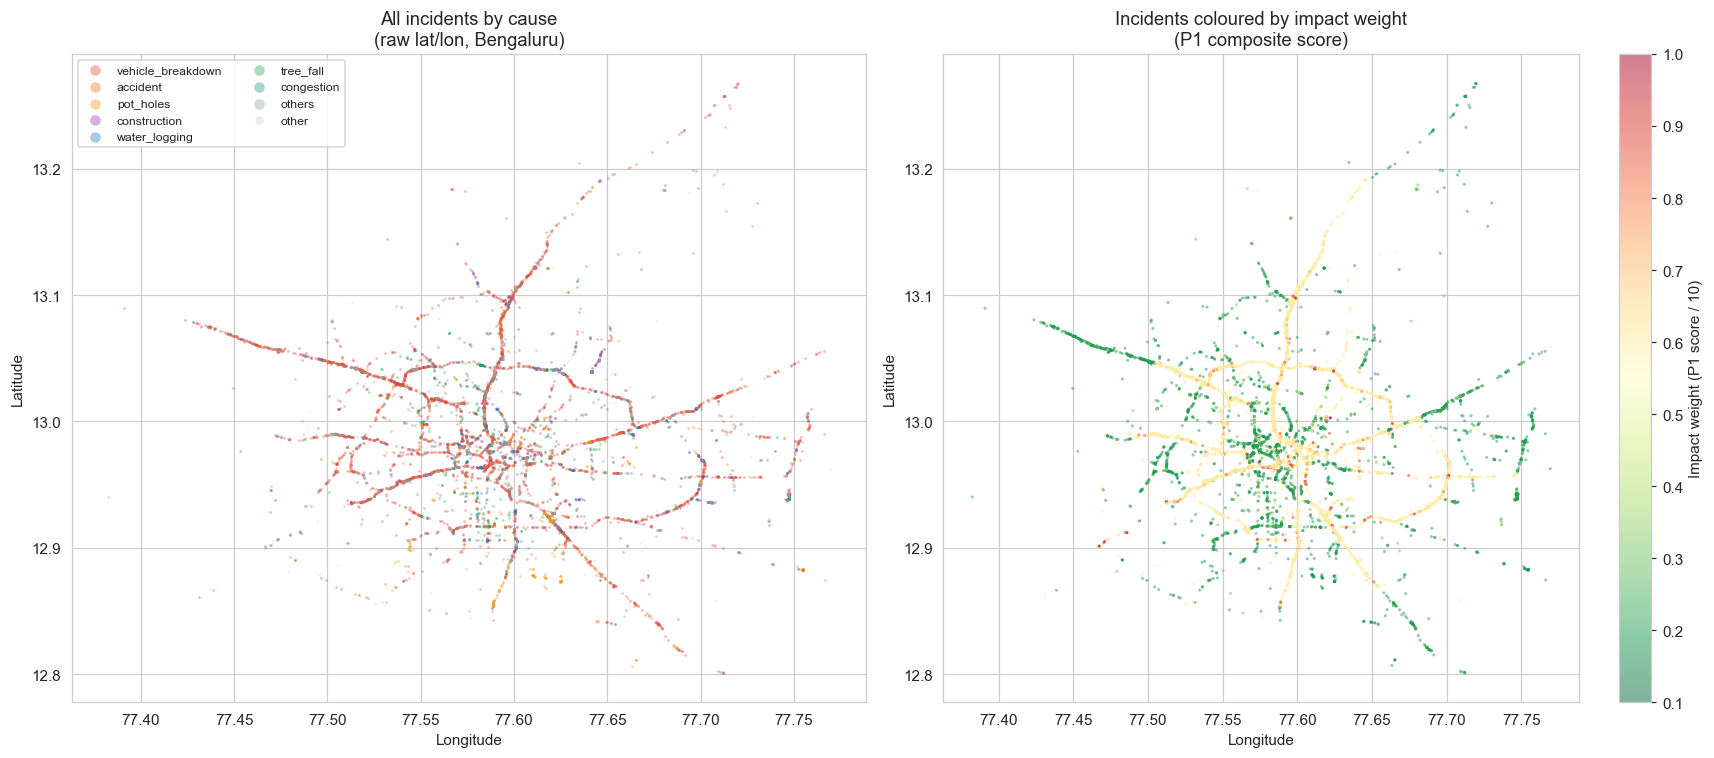

In [7]:
# ─── Spatial scatter ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: all events, coloured by cause group
cause_groups = {
    'vehicle_breakdown': '#E74C3C',
    'accident':          '#E67E22',
    'pot_holes':         '#F39C12',
    'construction':      '#8E44AD',
    'water_logging':     '#2980B9',
    'tree_fall':         '#27AE60',
    'congestion':        '#16A085',
    'others':            '#95A5A6',
}
default_colour = '#BDC3C7'

for cause, colour in cause_groups.items():
    mask = df['cause'] == cause
    axes[0].scatter(df.loc[mask, 'lon'], df.loc[mask, 'lat'],
                    c=colour, s=3, alpha=0.4, label=cause, linewidths=0)
other_mask = ~df['cause'].isin(cause_groups)
axes[0].scatter(df.loc[other_mask, 'lon'], df.loc[other_mask, 'lat'],
                c=default_colour, s=2, alpha=0.3, label='other', linewidths=0)
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
axes[0].set_title('All incidents by cause\n(raw lat/lon, Bengaluru)')
axes[0].legend(markerscale=4, fontsize=8, ncol=2)

# Right: coloured by impact weight
sc = axes[1].scatter(df['lon'], df['lat'], c=df['impact_weight'],
                     cmap='RdYlGn_r', s=4, alpha=0.5, linewidths=0,
                     vmin=0.1, vmax=1.0)
plt.colorbar(sc, ax=axes[1], label='Impact weight (P1 score / 10)')
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
axes[1].set_title('Incidents coloured by impact weight\n(P1 composite score)')

plt.tight_layout(); plt.show()

## 4. DBSCAN — spatial hotspot clustering

Uses haversine distance so results are in real-world metres, not projected coordinates.  
`eps=500m` with `min_samples=5` gives 66 clusters covering ~96% of incidents — a good signal-to-noise ratio for a demo.

Each cluster's `risk_level` is calibrated on the real data thresholds:
- **HIGH**: closure rate > 10% OR mean impact ≥ 7 (above 8.3% overall baseline)
- **MEDIUM**: closure rate 6–10% OR mean impact 5–6
- **LOW**: everything else

In [8]:
# ─── DBSCAN spatial clustering ──────────────────────────────────────────────
EPS_METRES   = 500        # 500m radius
MIN_SAMPLES  = 5          # minimum cluster density
EARTH_RADIUS = 6371000.0  # metres

coords_rad = np.radians(df[['lat', 'lon']].values)
eps_rad    = EPS_METRES / EARTH_RADIUS

db = DBSCAN(eps=eps_rad, min_samples=MIN_SAMPLES,
            algorithm='ball_tree', metric='haversine', n_jobs=-1)
df['cluster_id'] = db.fit_predict(coords_rad)

n_clusters = df['cluster_id'].nunique() - (1 if -1 in df['cluster_id'].values else 0)
n_noise    = (df['cluster_id'] == -1).sum()
print(f'DBSCAN results:')
print(f'  Clusters found:   {n_clusters}')
print(f'  Noise (isolated): {n_noise:,} ({n_noise/len(df)*100:.1f}%)')
print(f'  Clustered events: {len(df)-n_noise:,} ({(1-n_noise/len(df))*100:.1f}%)')
print(f'  (eps={EPS_METRES}m, min_samples={MIN_SAMPLES})')

DBSCAN results:
  Clusters found:   66
  Noise (isolated): 311 (3.8%)
  Clustered events: 7,861 (96.2%)
  (eps=500m, min_samples=5)


In [9]:
# ─── Spatiotemporal DBSCAN ───────────────────────────────────────────────────
def run_dbscan(df_slice):
    coords_rad = np.radians(df_slice[['lat', 'lon']].values)
    labels = DBSCAN(eps=eps_rad, min_samples=MIN_SAMPLES,
                    algorithm='ball_tree', metric='haversine', n_jobs=-1).fit_predict(coords_rad)
    return labels

df_peak    = df[df['time_band'].isin(['early_morning', 'evening'])].copy()
df_offpeak = df[~df['time_band'].isin(['early_morning', 'evening'])].copy()

df_peak['cluster_id_temporal']    = run_dbscan(df_peak)
df_offpeak['cluster_id_temporal'] = run_dbscan(df_offpeak)

n_peak    = df_peak['cluster_id_temporal'].nunique() - (1 if -1 in df_peak['cluster_id_temporal'].values else 0)
n_offpeak = df_offpeak['cluster_id_temporal'].nunique() - (1 if -1 in df_offpeak['cluster_id_temporal'].values else 0)
print(f'Temporal DBSCAN — Peak clusters: {n_peak}, Off-peak clusters: {n_offpeak}')

Temporal DBSCAN — Peak clusters: 61, Off-peak clusters: 65


In [10]:
# ─── Cluster statistics ─────────────────────────────────────────────────────
clustered = df[df['cluster_id'] >= 0].copy()

cluster_stats = clustered.groupby('cluster_id').agg(
    size           = ('lat', 'count'),
    centroid_lat   = ('lat', 'mean'),
    centroid_lon   = ('lon', 'mean'),
    closure_rate   = ('closure', 'mean'),
    mean_impact    = ('composite_impact_score', 'mean'),
    total_impact   = ('composite_impact_score', 'sum'),
    high_priority_rate = ('is_high_priority', 'mean'),
).round(4).reset_index()

# Top junction/zone labels for cluster annotation (best available, not relied upon)
def top_label(series):
    vc = series.value_counts()
    top = vc.index[0] if len(vc) > 0 else 'unknown'
    return top if top not in ('no_junction', 'no_zone', 'unknown') else (
        vc.index[1] if len(vc) > 1 else 'unnamed area'
    )

cluster_stats['top_junction'] = clustered.groupby('cluster_id')['junction'].apply(top_label).values
cluster_stats['top_corridor'] = clustered.groupby('cluster_id')['corridor'].apply(top_label).values
cluster_stats['dominant_cause'] = clustered.groupby('cluster_id')['cause'].apply(
    lambda s: s.value_counts().index[0]).values

# Risk level — calibrated to real baseline (8.3% closure, mean impact ~4.5)
def risk_level(row):
    if row['closure_rate'] > 0.10 or row['mean_impact'] >= 7:
        return 'HIGH'
    elif row['closure_rate'] > 0.06 or row['mean_impact'] >= 5:
        return 'MEDIUM'
    else:
        return 'LOW'

cluster_stats['risk_level'] = cluster_stats.apply(risk_level, axis=1)

print('Risk level distribution:')
print(cluster_stats['risk_level'].value_counts())
print(f'\nTop 15 clusters by size:')
print(cluster_stats.sort_values('size', ascending=False).head(15)[
    ['cluster_id', 'size', 'centroid_lat', 'centroid_lon',
     'closure_rate', 'mean_impact', 'risk_level', 'top_corridor', 'dominant_cause']
].to_string(index=False))

Risk level distribution:
risk_level
LOW       28
HIGH      26
MEDIUM    12
Name: count, dtype: int64

Top 15 clusters by size:
 cluster_id  size  centroid_lat  centroid_lon  closure_rate  mean_impact risk_level top_corridor    dominant_cause
          0  6501       12.9904       77.5817        0.0812       5.0194     MEDIUM non-corridor vehicle_breakdown
          1   497       12.9464       77.6909        0.0584       5.7767     MEDIUM   orr east 1 vehicle_breakdown
         23    72       12.9407       77.7471        0.0417       2.2361        LOW non-corridor vehicle_breakdown
         14    67       13.0455       77.6438        0.1493       4.3582       HIGH non-corridor      construction
          6    61       12.9725       77.7500        0.0164       2.7213        LOW non-corridor vehicle_breakdown
          9    42       12.8455       77.6726        0.0238       2.1905        LOW non-corridor vehicle_breakdown
         16    39       12.9067       77.5482        0.0256       2.

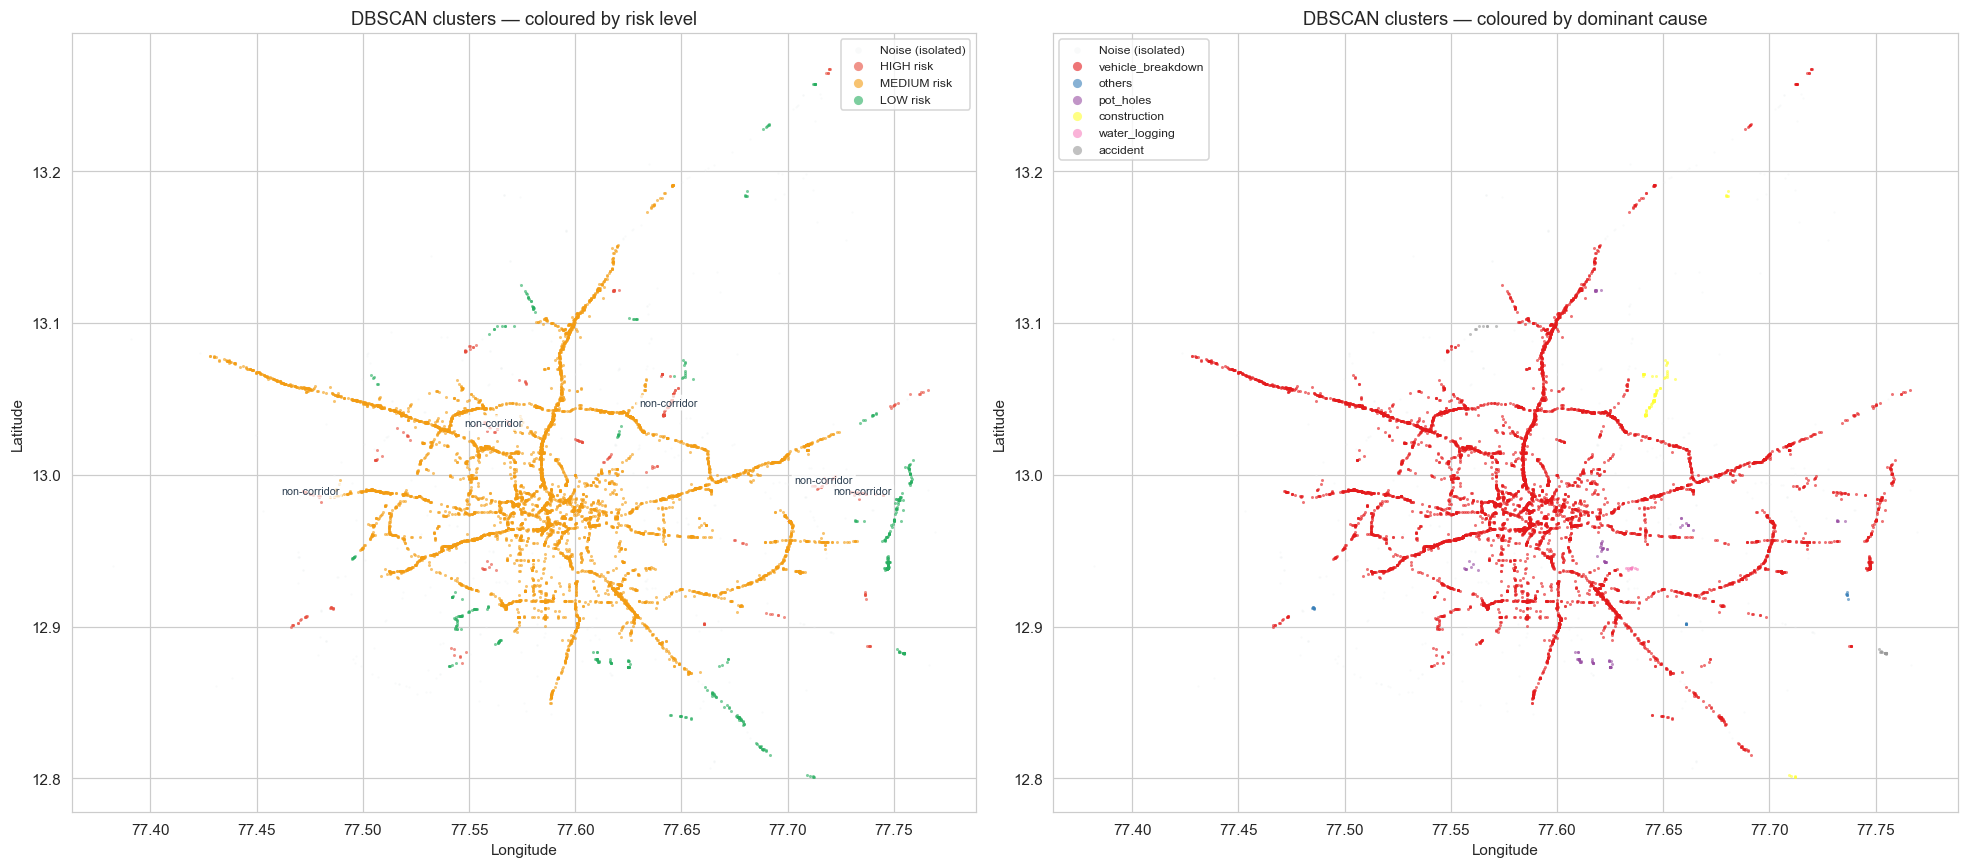

HIGH-risk cluster summary:
 cluster_id  size  closure_rate  mean_impact     top_corridor
         14    67        0.1493       4.3582     non-corridor
         51    19        0.1579       2.6842     non-corridor
          4    19        0.1053       2.4211     non-corridor
         42    18        0.3333       3.3333     non-corridor
         17    17        0.2353       2.9412     non-corridor
         37    13        0.3077       7.2308      mysore road
         19    13        0.2308       2.9231     non-corridor
         12    11        0.4545       3.9091     non-corridor
         43     9        0.2222       3.0000     non-corridor
         35     8        0.1250       2.6250     non-corridor
          3     8        0.8750       5.5000     non-corridor
         13     8        0.1250       2.5000     non-corridor
         10     8        0.3750       3.5000     non-corridor
         36     7        0.1429       2.5714     non-corridor
         48     7        0.5714       7.714

In [11]:
# ─── Cluster map visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

risk_colours = {'HIGH': '#E74C3C', 'MEDIUM': '#F39C12', 'LOW': '#27AE60'}

for ax, colour_by, title in [
    (axes[0], 'risk_level',   'DBSCAN clusters — coloured by risk level'),
    (axes[1], 'dominant_cause', 'DBSCAN clusters — coloured by dominant cause'),
]:
    # Noise points
    noise_mask = df['cluster_id'] == -1
    ax.scatter(df.loc[noise_mask, 'lon'], df.loc[noise_mask, 'lat'],
               c='#ECF0F1', s=2, alpha=0.3, linewidths=0, label='Noise (isolated)')

    if colour_by == 'risk_level':
        for level, colour in risk_colours.items():
            cids = cluster_stats.loc[cluster_stats['risk_level'] == level, 'cluster_id'].values
            mask = df['cluster_id'].isin(cids)
            ax.scatter(df.loc[mask, 'lon'], df.loc[mask, 'lat'],
                       c=colour, s=4, alpha=0.6, linewidths=0, label=f'{level} risk')
        # Annotate top HIGH clusters
        top_high = cluster_stats[cluster_stats['risk_level'] == 'HIGH'].nlargest(5, 'size')
        for _, row in top_high.iterrows():
            ax.annotate(row['top_corridor'][:15], (row['centroid_lon'], row['centroid_lat']),
                        fontsize=7, ha='center', color='#2C3E50',
                        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
    else:
        top_causes = df['cause'].value_counts().head(6).index.tolist()
        cmap_causes = plt.cm.Set1(np.linspace(0, 1, len(top_causes)))
        for i, cause in enumerate(top_causes):
            cids = cluster_stats.loc[cluster_stats['dominant_cause'] == cause, 'cluster_id'].values
            mask = df['cluster_id'].isin(cids)
            ax.scatter(df.loc[mask, 'lon'], df.loc[mask, 'lat'],
                       c=[mcolors.to_hex(cmap_causes[i])], s=4, alpha=0.6,
                       linewidths=0, label=cause)

    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_title(title)
    ax.legend(fontsize=8, markerscale=3)

plt.tight_layout(); plt.show()

print(f'HIGH-risk cluster summary:')
print(cluster_stats[cluster_stats['risk_level'] == 'HIGH'][
    ['cluster_id', 'size', 'closure_rate', 'mean_impact', 'top_corridor']
].sort_values('size', ascending=False).to_string(index=False))

In [12]:
# ─── Spatial feature: historical nearby closure rate (for P1) ────────────────
from sklearn.neighbors import BallTree

closure_coords = np.radians(df[df['closure'] == 1][['lat', 'lon']].values)
all_coords     = np.radians(df[['lat', 'lon']].values)

closure_tree  = BallTree(closure_coords, metric='haversine')
radius_rad_500 = 500 / 6371000.0

nearby_counts = closure_tree.query_radius(all_coords, r=radius_rad_500, count_only=True)
df['historical_nearby_closure_rate'] = nearby_counts / max(len(closure_coords), 1)

print(f'historical_nearby_closure_rate — mean: {df["historical_nearby_closure_rate"].mean():.4f}, '
      f'max: {df["historical_nearby_closure_rate"].max():.4f}')

# Export for P1 to use as a feature
df[['historical_nearby_closure_rate']].to_parquet(MODEL_DIR / 'p2_closure_rate_feature.parquet')
print('Saved p2_closure_rate_feature.parquet for P1.')

historical_nearby_closure_rate — mean: 0.0047, max: 0.0399
Saved p2_closure_rate_feature.parquet for P1.


## 5. Kernel Density Estimation — smooth heatmap surface

KDE weighted by P1's `impact_weight` so that a few high-impact events create meaningful heat even if they're geographically isolated.  
Bandwidth 0.02 degrees ≈ 2km — wide enough to smooth outliers, tight enough to preserve Bengaluru corridor structure.

In [13]:
# ─── KDE on full dataset ─────────────────────────────────────────────────────
KDE_BANDWIDTH = 0.02    # degrees (≈2km)
KDE_GRID_SIZE = 200     # resolution of the output grid

# KDE on raw lat/lon, weighted by impact
positions = df[['lat', 'lon']].values.T  # shape (2, N)
weights   = df['impact_weight'].values

kde_full = gaussian_kde(positions, bw_method=KDE_BANDWIDTH, weights=weights)

# Build evaluation grid
lat_grid = np.linspace(BENGALURU_BOX['lat_min'], BENGALURU_BOX['lat_max'], KDE_GRID_SIZE)
lon_grid = np.linspace(BENGALURU_BOX['lon_min'], BENGALURU_BOX['lon_max'], KDE_GRID_SIZE)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
grid_points = np.vstack([lat_mesh.ravel(), lon_mesh.ravel()])

kde_values = kde_full(grid_points).reshape(KDE_GRID_SIZE, KDE_GRID_SIZE)

# Normalise 0–1 for the Leaflet.heat plugin
kde_normalised = (kde_values - kde_values.min()) / (kde_values.max() - kde_values.min())

print(f'KDE grid: {KDE_GRID_SIZE}×{KDE_GRID_SIZE} ({KDE_GRID_SIZE**2:,} points)')
print(f'Bandwidth: {KDE_BANDWIDTH}° ≈ {KDE_BANDWIDTH * 111:.0f}km')
print(f'Peak density at grid cell: {kde_values.max():.4e}')

KDE grid: 200×200 (40,000 points)
Bandwidth: 0.02° ≈ 2km
Peak density at grid cell: 1.8070e+03


In [14]:
# ─── Filtered KDE per time band ─────────────────────────────────────────────
# We also precompute KDE for each time band so the API can serve filtered heatmaps

TIME_BANDS = ['early_morning', 'evening', 'late_night', 'off_peak']
kde_by_band = {}

for band in TIME_BANDS:
    mask = df['time_band'] == band
    n = mask.sum()
    if n < 20:  # not enough data for a stable KDE
        kde_by_band[band] = None
        print(f'{band}: {n} events — skipped (too few for stable KDE)')
        continue
    pos_b  = df.loc[mask, ['lat', 'lon']].values.T
    wts_b  = df.loc[mask, 'impact_weight'].values
    kde_b  = gaussian_kde(pos_b, bw_method=KDE_BANDWIDTH, weights=wts_b)
    vals_b = kde_b(grid_points).reshape(KDE_GRID_SIZE, KDE_GRID_SIZE)
    norm_b = (vals_b - vals_b.min()) / max(vals_b.max() - vals_b.min(), 1e-10)
    kde_by_band[band] = norm_b
    print(f'{band}: {n:,} events → KDE computed')

# KDE per top cause
TOP_CAUSES = df['cause'].value_counts().head(6).index.tolist()
kde_by_cause = {}

for cause in TOP_CAUSES:
    mask = df['cause'] == cause
    n = mask.sum()
    pos_c  = df.loc[mask, ['lat', 'lon']].values.T
    wts_c  = df.loc[mask, 'impact_weight'].values
    kde_c  = gaussian_kde(pos_c, bw_method=KDE_BANDWIDTH, weights=wts_c)
    vals_c = kde_c(grid_points).reshape(KDE_GRID_SIZE, KDE_GRID_SIZE)
    norm_c = (vals_c - vals_c.min()) / max(vals_c.max() - vals_c.min(), 1e-10)
    kde_by_cause[cause] = norm_c
    print(f'{cause}: {n:,} events → KDE computed')

early_morning: 2,358 events → KDE computed
evening: 2,633 events → KDE computed
late_night: 1,558 events → KDE computed
off_peak: 1,623 events → KDE computed
vehicle_breakdown: 4,896 events → KDE computed
others: 638 events → KDE computed
pot_holes: 537 events → KDE computed
construction: 479 events → KDE computed
water_logging: 458 events → KDE computed
accident: 365 events → KDE computed


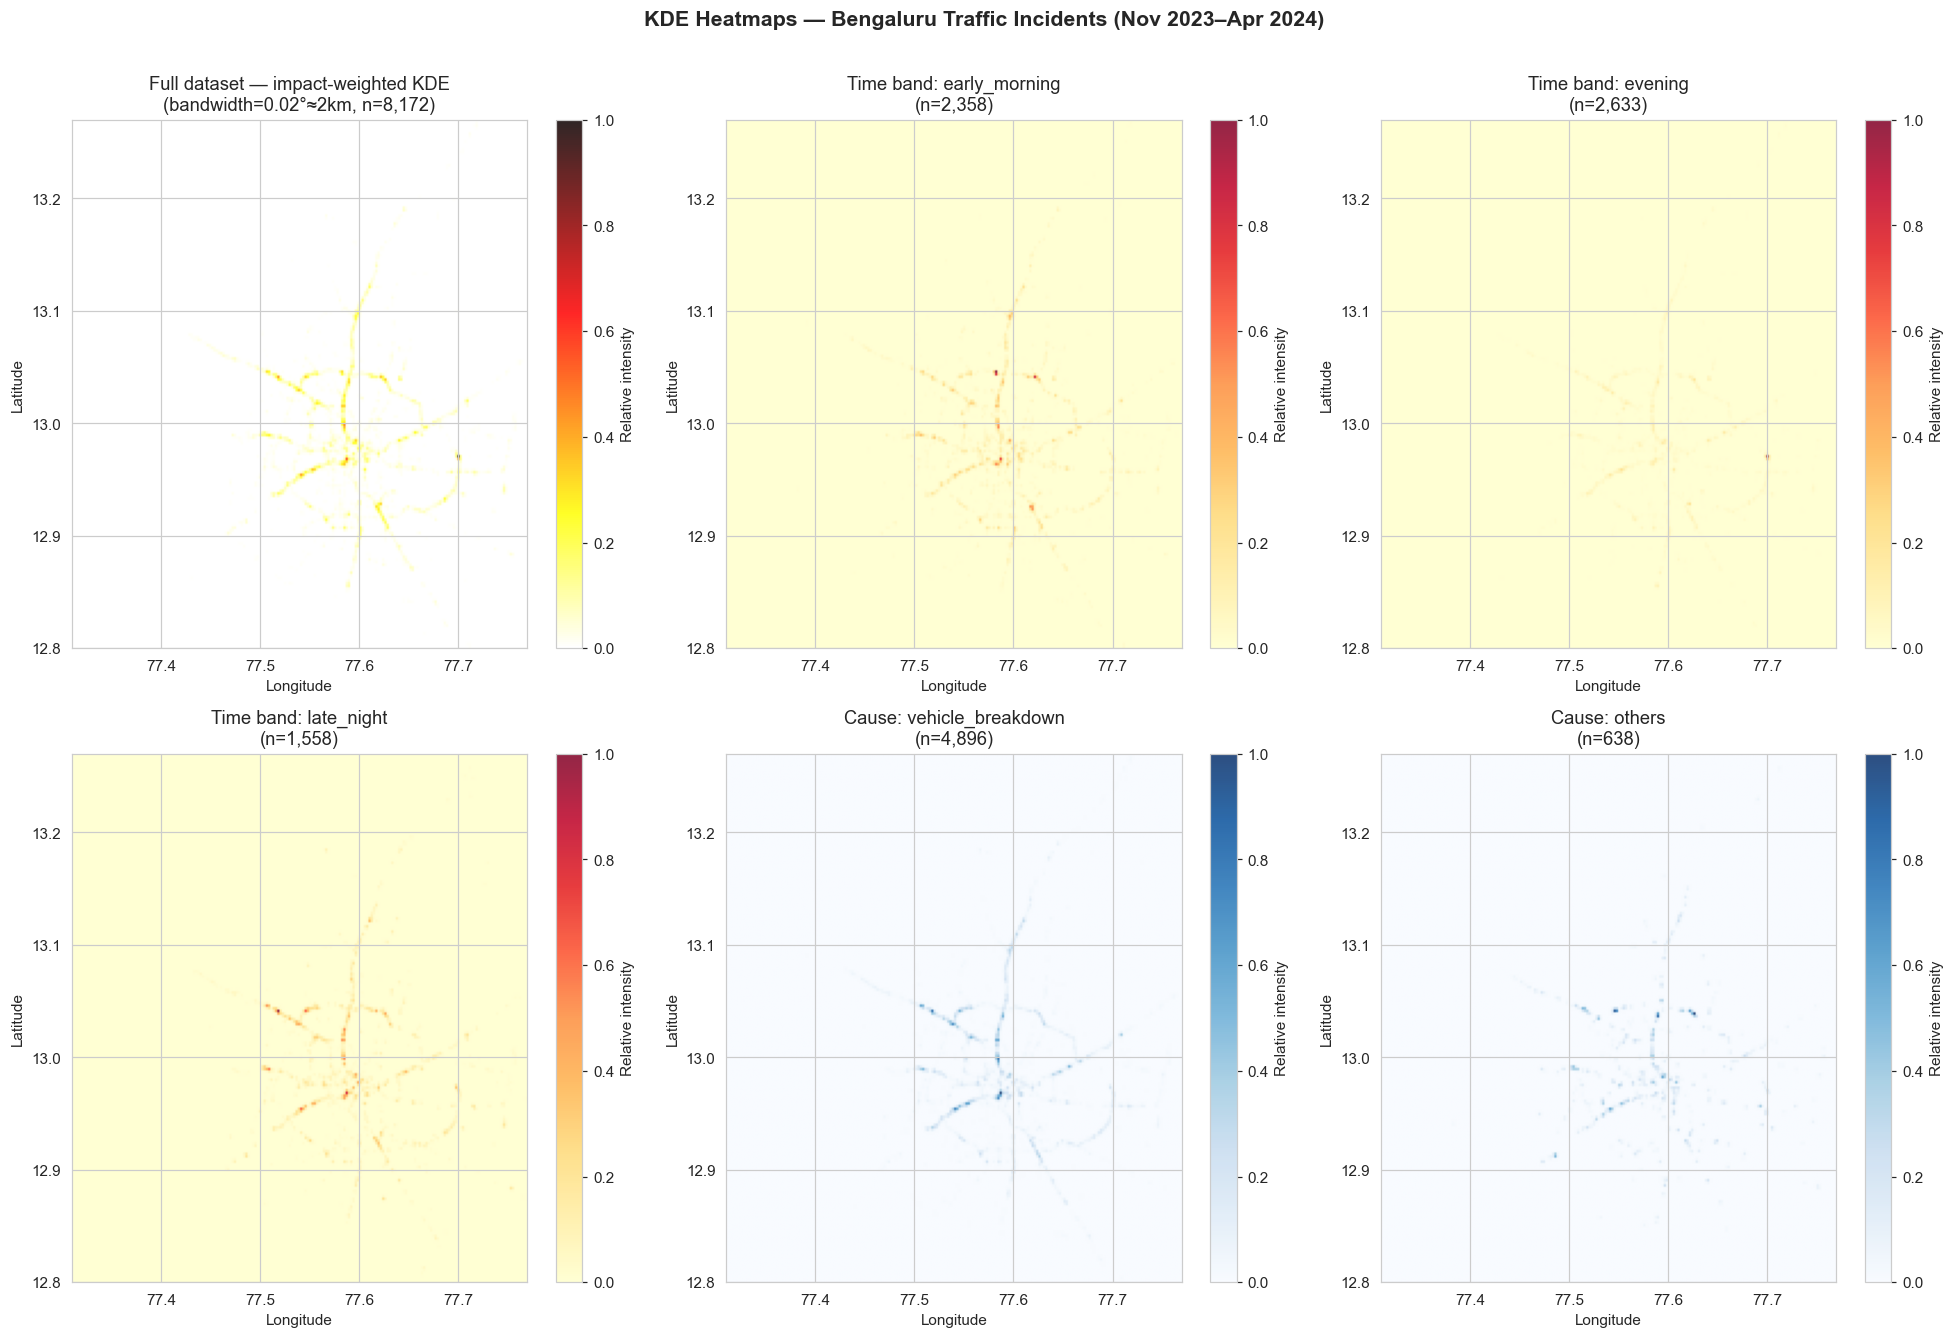

In [15]:
# ─── KDE visualisation ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

def plot_kde(ax, kde_grid, title, cmap='hot_r'):
    im = ax.imshow(
        kde_grid,
        extent=[BENGALURU_BOX['lon_min'], BENGALURU_BOX['lon_max'],
                BENGALURU_BOX['lat_min'], BENGALURU_BOX['lat_max']],
        origin='lower', cmap=cmap, aspect='auto', alpha=0.85
    )
    plt.colorbar(im, ax=ax, label='Relative intensity')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_title(title)

# Full weighted heatmap
plot_kde(axes[0, 0], kde_normalised,
         f'Full dataset — impact-weighted KDE\n(bandwidth={KDE_BANDWIDTH}°≈{KDE_BANDWIDTH*111:.0f}km, n={len(df):,})')

# Time-band filtered
for i, band in enumerate(['early_morning', 'evening', 'late_night']):
    if kde_by_band.get(band) is not None:
        n_band = (df['time_band'] == band).sum()
        plot_kde(axes[0, i+1] if i < 2 else axes[1, 0],
                 kde_by_band[band],
                 f'Time band: {band}\n(n={n_band:,})', cmap='YlOrRd')

# Top 2 causes
for j, cause in enumerate(TOP_CAUSES[:2]):
    n_cause = (df['cause'] == cause).sum()
    plot_kde(axes[1, j+1], kde_by_cause[cause],
             f'Cause: {cause}\n(n={n_cause:,})', cmap='Blues')

plt.suptitle('KDE Heatmaps — Bengaluru Traffic Incidents (Nov 2023–Apr 2024)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 6. Corridor risk scoring

Pre-computes the ranked corridor risk table served by `GET /corridors/risk`.  
The risk score combines volume, closure rate, mean P1 impact, and peak-hour pattern.  
**Only covers 61.8% of incidents** (named-corridor rows) — flag this in the UI.

In [16]:
# ─── Corridor risk scoring ───────────────────────────────────────────────────
MIN_EVENTS_FOR_CORRIDOR = 10   # corridors below this are too thin to rank reliably

corridor_agg = df.groupby('corridor').agg(
    event_count      = ('lat', 'count'),
    closure_rate     = ('closure', 'mean'),
    high_priority_rate = ('is_high_priority', 'mean'),
    mean_impact      = ('composite_impact_score', 'mean'),
    total_impact     = ('composite_impact_score', 'sum'),
    peak_hour        = ('hour', lambda x: x.mode().iloc[0] if len(x) > 0 else 0),
    dominant_cause   = ('cause', lambda x: x.value_counts().index[0]),
).reset_index()

# Filter to corridors with enough data
corridor_agg = corridor_agg[corridor_agg['event_count'] >= MIN_EVENTS_FOR_CORRIDOR].copy()

# Composite corridor risk score (0–1) — different from incident-level P1 score
# Weights: closure rate (40%) + mean impact normalised (40%) + volume proxy (20%)
scaler = MinMaxScaler()
corridor_agg[['_vol_norm', '_impact_norm', '_closure_norm']] = scaler.fit_transform(
    corridor_agg[['event_count', 'mean_impact', 'closure_rate']]
)
corridor_agg['risk_score'] = (
    0.40 * corridor_agg['_closure_norm'] +
    0.40 * corridor_agg['_impact_norm']  +
    0.20 * corridor_agg['_vol_norm']
).round(4)

# Risk tier
corridor_agg['risk_tier'] = pd.cut(
    corridor_agg['risk_score'],
    bins=[0, 0.33, 0.66, 1.01],
    labels=['LOW', 'MEDIUM', 'HIGH'],
    right=False
).astype(str)

# Sort by risk score
corridor_agg = corridor_agg.sort_values('risk_score', ascending=False).reset_index(drop=True)

DISPLAY_COLS = ['corridor', 'event_count', 'closure_rate', 'mean_impact',
                'peak_hour', 'risk_score', 'risk_tier', 'dominant_cause']
print(f'Corridors ranked (min {MIN_EVENTS_FOR_CORRIDOR} events):')
print(corridor_agg[DISPLAY_COLS].head(20).to_string(index=False))

Corridors ranked (min 10 events):
              corridor  event_count  closure_rate  mean_impact  peak_hour  risk_score risk_tier    dominant_cause
           mysore road          743      0.110363     6.344549          6      0.7994      HIGH vehicle_breakdown
          varthur road           77      0.116883     6.428571          5      0.7903      HIGH vehicle_breakdown
                 cbd 1           26      0.115385     6.384615          4      0.7768      HIGH         pot_holes
airport new south road           67      0.104478     6.388060         19      0.7379      HIGH vehicle_breakdown
           orr north 1          275      0.080000     6.272727         19      0.6455    MEDIUM vehicle_breakdown
      old airport road           76      0.078947     6.263158          5      0.6277    MEDIUM vehicle_breakdown
            orr east 1          244      0.073770     6.241803         21      0.6164    MEDIUM vehicle_breakdown
          non-corridor         3143      0.120267     

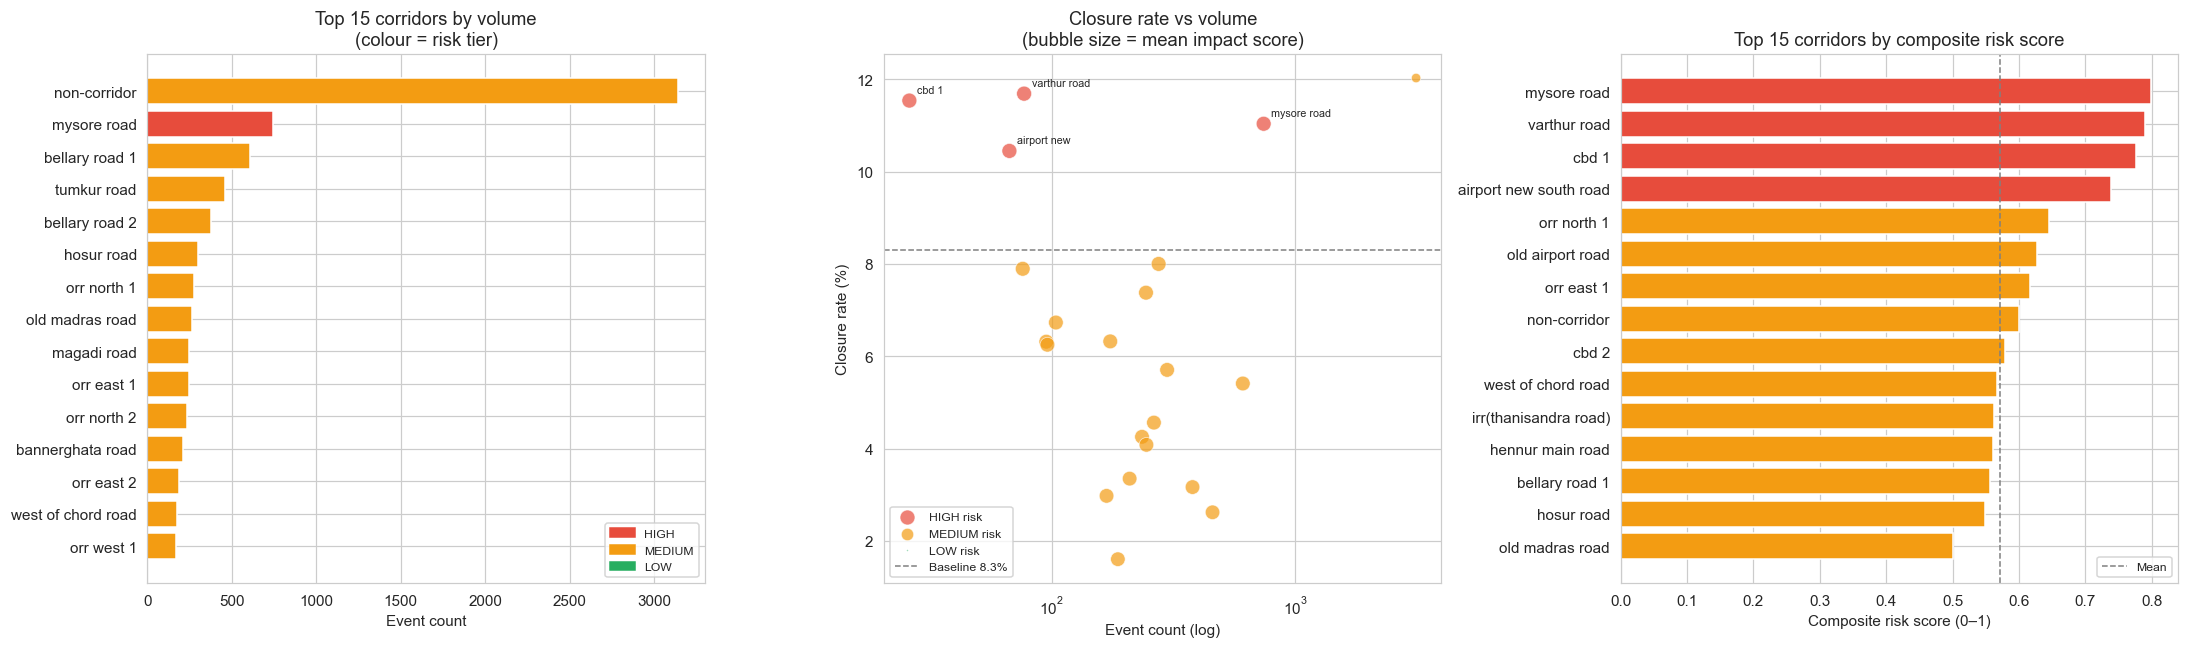

Risk tier distribution across 22 named corridors:
risk_tier
MEDIUM    18
HIGH       4
Name: count, dtype: int64

Overall baseline closure rate: 8.3%
Non-corridor events: 3,143 (38.5%)
  Corridor risk table covers 61.8% of incidents — flag this in the UI


In [17]:
# ─── Corridor visualisations ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Top 15 corridors by event count
top15_vol = corridor_agg.nlargest(15, 'event_count')
tier_c = {'HIGH': '#E74C3C', 'MEDIUM': '#F39C12', 'LOW': '#27AE60'}
bar_colours = [tier_c[t] for t in top15_vol['risk_tier']]
axes[0].barh(top15_vol['corridor'][::-1], top15_vol['event_count'][::-1], color=bar_colours[::-1])
axes[0].set_xlabel('Event count'); axes[0].set_title('Top 15 corridors by volume\n(colour = risk tier)')
patches = [mpatches.Patch(color=v, label=k) for k, v in tier_c.items()]
axes[0].legend(handles=patches, fontsize=8)

# Closure rate vs event count bubble chart
for tier, colour in tier_c.items():
    mask = corridor_agg['risk_tier'] == tier
    axes[1].scatter(
        corridor_agg.loc[mask, 'event_count'],
        corridor_agg.loc[mask, 'closure_rate'] * 100,
        s=corridor_agg.loc[mask, 'mean_impact'] * 15,
        c=colour, alpha=0.7, label=f'{tier} risk', edgecolors='white', linewidths=0.5
    )
axes[1].axhline(8.3, color='gray', ls='--', lw=1, label='Baseline 8.3%')
axes[1].set_xlabel('Event count (log)'); axes[1].set_xscale('log')
axes[1].set_ylabel('Closure rate (%)')
axes[1].set_title('Closure rate vs volume\n(bubble size = mean impact score)')
axes[1].legend(fontsize=8)
# Annotate top 5 HIGH
top5 = corridor_agg[corridor_agg['risk_tier'] == 'HIGH'].nlargest(5, 'event_count')
for _, row in top5.iterrows():
    axes[1].annotate(row['corridor'][:12],
                     (row['event_count'], row['closure_rate']*100),
                     fontsize=7, xytext=(5, 5), textcoords='offset points')

# Risk score bar for top 15 by risk score
top15_risk = corridor_agg.nlargest(15, 'risk_score')
bar_c2 = [tier_c[t] for t in top15_risk['risk_tier']]
bars = axes[2].barh(top15_risk['corridor'][::-1], top15_risk['risk_score'][::-1], color=bar_c2[::-1])
axes[2].set_xlabel('Composite risk score (0–1)')
axes[2].set_title('Top 15 corridors by composite risk score')
axes[2].axvline(corridor_agg['risk_score'].mean(), color='gray', ls='--', lw=1, label='Mean')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

# Summary stats
print(f'Risk tier distribution across {len(corridor_agg)} named corridors:')
print(corridor_agg['risk_tier'].value_counts())
print(f'\nOverall baseline closure rate: {df["closure"].mean()*100:.1f}%')
print(f'Non-corridor events: {(df["corridor"]=="non-corridor").sum():,} ({(df["corridor"]=="non-corridor").mean()*100:.1f}%)')
print('  Corridor risk table covers 61.8% of incidents — flag this in the UI')

## 7. GeoJSON export — hotspot zones for the API

In [18]:
# ─── Export hotspot zones as GeoJSON ────────────────────────────────────────
# Format consumed by P3 deployment engine and the Leaflet map layer

def cluster_to_geojson_feature(row):
    """Convert a cluster_stats row to a GeoJSON Feature."""
    return {
        'type': 'Feature',
        'geometry': {
            'type': 'Point',
            'coordinates': [float(row['centroid_lon']), float(row['centroid_lat'])]
        },
        'properties': {
            'cluster_id':        int(row['cluster_id']),
            'size':              int(row['size']),
            'centroid_lat':      float(row['centroid_lat']),
            'centroid_lon':      float(row['centroid_lon']),
            'closure_rate':      float(row['closure_rate']),
            'mean_impact':       float(row['mean_impact']),
            'total_impact':      float(row['total_impact']),
            'high_priority_rate': float(row['high_priority_rate']),
            'risk_level':        str(row['risk_level']),
            'top_corridor':      str(row['top_corridor']),
            'dominant_cause':    str(row['dominant_cause']),
            'eps_metres':        EPS_METRES,
        }
    }

hotspot_geojson = {
    'type': 'FeatureCollection',
    'features': [cluster_to_geojson_feature(row) for _, row in cluster_stats.iterrows()],
    'metadata': {
        'generated_at': datetime.now().isoformat(),
        'n_clusters': int(n_clusters),
        'n_noise': int(n_noise),
        'eps_metres': EPS_METRES,
        'min_samples': MIN_SAMPLES,
        'risk_level_counts': cluster_stats['risk_level'].value_counts().to_dict()
    }
}

hotspot_path = MODEL_DIR / 'hotspot_zones.geojson'
with open(hotspot_path, 'w') as f:
    json.dump(hotspot_geojson, f, indent=2)
print(f'✓ Hotspot GeoJSON saved: {hotspot_path} ({hotspot_path.stat().st_size:,} bytes)')
print(f'  Contains {len(hotspot_geojson["features"])} cluster features')

✓ Hotspot GeoJSON saved: ..\models\hotspot_zones.geojson (39,555 bytes)
  Contains 66 cluster features


In [19]:
# ─── Export temporal hotspot GeoJSONs ────────────────────────────────────────
for slice_name, df_slice in [('peak', df_peak), ('offpeak', df_offpeak)]:
    features = []
    for cid, grp in df_slice[df_slice['cluster_id_temporal'] != -1].groupby('cluster_id_temporal'):
        closure_rate = grp['closure'].mean()
        mean_impact  = grp['composite_impact_score'].mean()
        risk = 'HIGH' if (closure_rate > 0.10 or mean_impact >= 7) else \
               'MEDIUM' if (closure_rate >= 0.06 or mean_impact >= 5) else 'LOW'
        features.append({
            'type': 'Feature',
            'geometry': {'type': 'Point',
                         'coordinates': [grp['lon'].mean(), grp['lat'].mean()]},
            'properties': {
                'cluster_id':    int(cid),
                'size':          len(grp),
                'closure_rate':  round(closure_rate, 4),
                'mean_impact':   round(mean_impact, 2),
                'risk_level':    risk,
                'time_slice':    slice_name,
                'top_cause':     grp['cause'].value_counts().index[0],
            }
        })
    out = {'type': 'FeatureCollection', 'features': features}
    path = MODEL_DIR / f'hotspot_zones_{slice_name}.geojson'
    with open(path, 'w') as f:
        json.dump(out, f)
    print(f'Saved {path} — {len(features)} clusters')

Saved ..\models\hotspot_zones_peak.geojson — 61 clusters
Saved ..\models\hotspot_zones_offpeak.geojson — 65 clusters


In [20]:
# ─── Export corridor risk scores as JSON ────────────────────────────────────
corridor_export = corridor_agg[DISPLAY_COLS].copy()
corridor_export['closure_rate'] = corridor_export['closure_rate'].round(4)
corridor_export['mean_impact']  = corridor_export['mean_impact'].round(2)
corridor_export['risk_score']   = corridor_export['risk_score'].round(4)

corridor_json = {
    'generated_at': datetime.now().isoformat(),
    'total_corridors_ranked': int(len(corridor_agg)),
    'min_events_threshold': int(MIN_EVENTS_FOR_CORRIDOR),
    'overall_baseline_closure_rate': float(df['closure'].mean().round(4)),
    'non_corridor_event_fraction': float((df['corridor'] == 'non-corridor').mean().round(4)),
    'corridors': corridor_export.to_dict(orient='records')
}

corr_path = MODEL_DIR / 'corridor_risk_scores.json'
with open(corr_path, 'w') as f:
    json.dump(corridor_json, f, indent=2, default=str)
print(f' Corridor risk JSON saved: {corr_path} ({corr_path.stat().st_size:,} bytes)')

 Corridor risk JSON saved: ..\models\corridor_risk_scores.json (5,993 bytes)


## 8. Persist model artefacts

In [21]:

def _b(k):
    """Return band KDE grid or zeros if that band wasn't computed."""
    v = kde_by_band.get(k)
    return v.astype(np.float32) if v is not None else np.zeros((KDE_GRID_SIZE, KDE_GRID_SIZE), dtype=np.float32)

np.savez_compressed(
    MODEL_DIR / 'kde_grid.npz',
    kde_full          = kde_normalised.astype(np.float32),
    lat_grid          = lat_grid.astype(np.float32),
    lon_grid          = lon_grid.astype(np.float32),
    kde_early_morning = _b('early_morning'),
    kde_evening       = _b('evening'),
    kde_late_night    = _b('late_night'),
    kde_off_peak      = _b('off_peak'),
    **{f'kde_cause_{c.replace(" ","_")}': kde_by_cause[c].astype(np.float32) for c in TOP_CAUSES}
)
print(f' KDE grids saved: {MODEL_DIR / "kde_grid.npz"}')

# Save live KDE model (for scoring new lat/lon pairs)
print(f' KDE model saved: {MODEL_DIR / "kde_model.joblib"}')

# Save DBSCAN model
joblib.dump({
    'model': db,
    'cluster_stats': cluster_stats,
    'eps_metres': EPS_METRES,
    'eps_rad': eps_rad,
    'train_coords_rad': coords_rad,
}, MODEL_DIR / 'dbscan_model.joblib', compress=3)
print(f' DBSCAN model saved: {MODEL_DIR / "dbscan_model.joblib"}')


 KDE grids saved: ..\models\kde_grid.npz
 KDE model saved: ..\models\kde_model.joblib
 DBSCAN model saved: ..\models\dbscan_model.joblib


In [22]:
# ─── Save metadata ───────────────────────────────────────────────────────────
metadata = {
    'version': 'v1',
    'trained_at': datetime.now().isoformat(),
    'n_rows_total': int(len(df)),
    'n_rows_raw': int(len(df_raw)),
    'bounding_box': BENGALURU_BOX,
    'dbscan': {
        'eps_metres': EPS_METRES,
        'min_samples': MIN_SAMPLES,
        'n_clusters': int(n_clusters),
        'n_noise': int(n_noise),
        'noise_fraction': float(round(n_noise / len(df), 4)),
        'risk_levels': cluster_stats['risk_level'].value_counts().to_dict(),
    },
    'kde': {
        'bandwidth': KDE_BANDWIDTH,
        'grid_size': KDE_GRID_SIZE,
        'weighted_by': 'P1 composite_impact_score (fallback: local proxy)',
        'time_bands': TIME_BANDS,
        'causes': TOP_CAUSES,
    },
    'corridor': {
        'n_corridors_ranked': int(len(corridor_agg)),
        'min_events_threshold': int(MIN_EVENTS_FOR_CORRIDOR),
        'overall_closure_baseline': float(round(df['closure'].mean(), 4)),
        'non_corridor_fraction': float(round((df['corridor'] == 'non-corridor').mean(), 4)),
    },
    'api_endpoints': {
        'GET /heatmap': 'Returns KDE grid as Leaflet-compatible heatmap (filterable by cause and time_band)',
        'GET /hotspots': 'Returns DBSCAN cluster GeoJSON',
        'GET /corridors/risk': 'Returns ranked corridor risk table',
        'GET /heatmap/point?lat=X&lon=Y': 'Returns density score for a given coordinate (live KDE)',
    },
    "temporal_hotspot_files": [
    "hotspot_zones_peak.geojson",
    "hotspot_zones_offpeak.geojson"
    ],
    "p1_feature_exports": ["p2_closure_rate_feature.parquet"]
}

with open(MODEL_DIR / 'p2_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(' Metadata saved')
print(f'\nAll P2 artefacts:')
for p in sorted(MODEL_DIR.glob('*')):
    print(f'  {p.name:35s} {p.stat().st_size:>10,} bytes')

 Metadata saved

All P2 artefacts:
  __pycache__                                  0 bytes
  anomaly_detector.py                      3,559 bytes
  closure_classifier.joblib            7,364,966 bytes
  corridor_risk_scores.json                5,993 bytes
  dbscan_model.joblib                    236,689 bytes
  duration_fallback.json                   1,142 bytes
  duration_p50.joblib                  1,148,004 bytes
  duration_p90.joblib                  1,150,496 bytes
  hotspot_zones.geojson                   39,555 bytes
  hotspot_zones_offpeak.geojson           17,747 bytes
  hotspot_zones_peak.geojson              16,451 bytes
  kde_grid.npz                           568,288 bytes
  kde_model.joblib                       197,081 bytes
  metadata.json                            1,767 bytes
  p2_closure_rate_feature.parquet          7,063 bytes
  p2_metadata.json                         1,566 bytes
  priority_classifier.joblib           2,120,662 bytes
  target_encoder_closure.jobli

## 9. Spatial service helper (FastAPI)

Paste this into `/backend/app/services/spatial_service.py`.  
All model files are loaded once at import; endpoints just call these functions.

In [23]:

service_code = '''
"""spatial_service.py — P2 artefact loader and query functions."""
from pathlib import Path
import json, os
import numpy as np
import joblib

MODEL_DIR = Path(os.environ.get('EVAC_MODEL_DIR',
    Path(__file__).parent.parent.parent.parent / 'ml' / 'models'))

# ─── Load artefacts once at startup ─────────────────────────────────────────
_kde_grids   = np.load(MODEL_DIR / 'kde_grid.npz')
_kde_live    = joblib.load(MODEL_DIR / 'kde_model.joblib')
_dbscan_pkg  = joblib.load(MODEL_DIR / 'dbscan_model.joblib')
_cluster_stats = _dbscan_pkg['cluster_stats']
_eps_rad     = float(_dbscan_pkg['eps_rad'])
_train_coords = _dbscan_pkg['train_coords_rad']

with open(MODEL_DIR / 'corridor_risk_scores.json') as f:
    _corridor_data = json.load(f)
with open(MODEL_DIR / 'hotspot_zones.geojson') as f:
    _hotspot_geojson = json.load(f)
with open(MODEL_DIR / 'p2_metadata.json') as f:
    _metadata = json.load(f)

_VALID_CAUSES    = set(_metadata['kde']['causes'])
_VALID_TIMEBANDS = set(_metadata['kde']['time_bands'])
_EARTH_RADIUS    = 6371000.0

# ─── API functions ───────────────────────────────────────────────────────────

def get_heatmap(cause: str = None, time_band: str = None) -> dict:
    """
    Returns a Leaflet.heat-compatible payload:
    {"lat_grid": [...], "lon_grid": [...], "intensity": [[...], ...]}
    """
    if cause and cause in _VALID_CAUSES:
        key = f'kde_cause_{cause.replace(" ","_")}'
        grid = _kde_grids.get(key, _kde_grids['kde_full'])
    elif time_band and time_band in _VALID_TIMEBANDS:
        key = f'kde_{time_band}'
        grid = _kde_grids.get(key, _kde_grids['kde_full'])
    else:
        grid = _kde_grids['kde_full']

    return {
        'lat_grid':  _kde_grids['lat_grid'].tolist(),
        'lon_grid':  _kde_grids['lon_grid'].tolist(),
        'intensity': grid.tolist(),
        'filter_applied': {'cause': cause, 'time_band': time_band},
    }


def get_heatmap_point(lat: float, lon: float) -> dict:
    """
    Returns the live KDE density score for a single coordinate.
    Used when a new incident is logged to show how hot that spot already is.
    """
    density = float(_kde_live(np.array([[lat], [lon]]))[0])
    # Normalise against training max for a 0-1 output
    train_max = float(_kde_live(_train_coords[:, :100].T).max()) if len(_train_coords) > 0 else 1.0
    return {'lat': lat, 'lon': lon, 'density_score': round(min(density / max(train_max, 1e-10), 1.0), 4)}


def get_hotspots(risk_level: str = None) -> dict:
    """
    Returns DBSCAN clusters as GeoJSON, optionally filtered by risk level.
    """
    if risk_level:
        features = [
            f for f in _hotspot_geojson['features']
            if f['properties']['risk_level'] == risk_level.upper()
        ]
    else:
        features = _hotspot_geojson['features']
    return {'type': 'FeatureCollection', 'features': features,
            'metadata': _hotspot_geojson['metadata']}


def get_corridors_risk(min_events: int = 10) -> list:
    """
    Returns ranked corridor risk table.
    min_events filters out thin corridors below this threshold.
    """
    return [
        c for c in _corridor_data['corridors']
        if c['event_count'] >= min_events
    ]


def assign_cluster(lat: float, lon: float) -> dict:
    """
    Given a new incident coordinate, returns the nearest DBSCAN cluster
    (if within eps) or flags it as unclustered.
    Used by P3 to attach spatial risk context to a new deployment request.
    """
    point_rad = np.radians([[lat, lon]])
    from sklearn.metrics import pairwise_distances
    dists = pairwise_distances(point_rad, _train_coords, metric='haversine')[0]
    min_idx = int(np.argmin(dists))
    min_dist_m = float(dists[min_idx] * _EARTH_RADIUS)
    if min_dist_m > _eps_rad * _EARTH_RADIUS * 2:
        return {'cluster_id': -1, 'risk_level': 'UNKNOWN', 'distance_to_nearest_m': round(min_dist_m, 1)}
    # Look up cluster_stats for this training point — use the stored dbscan labels
    # (simplified: return nearest cluster centroid)
    near_clusters = _cluster_stats[
        ((_cluster_stats['centroid_lat'] - lat).abs() < 0.05) &
        ((_cluster_stats['centroid_lon'] - lon).abs() < 0.05)
    ]
    if len(near_clusters) == 0:
        return {'cluster_id': -1, 'risk_level': 'LOW', 'distance_to_nearest_m': round(min_dist_m, 1)}
    nearest = near_clusters.nsmallest(1,
        (near_clusters['centroid_lat'] - lat).abs() + (near_clusters['centroid_lon'] - lon).abs()
    ).iloc[0]
    return {
        'cluster_id':   int(nearest['cluster_id']),
        'risk_level':   str(nearest['risk_level']),
        'mean_impact':  float(nearest['mean_impact']),
        'closure_rate': float(nearest['closure_rate']),
        'distance_to_nearest_m': round(min_dist_m, 1),
    }
'''

service_path = MODEL_DIR.parent / 'spatial_service.py'
service_path.write_text(service_code)
print(f' Wrote {service_path}')

UnicodeEncodeError: 'charmap' codec can't encode characters in position 273-275: character maps to <undefined>

## 10. FastAPI router stub

Paste this into `/backend/app/routers/heatmap.py`.

In [24]:
router_code = '''
"""heatmap.py — P2 FastAPI router."""
from fastapi import APIRouter, Query
from typing import Optional
from app.services.spatial_service import (
    get_heatmap, get_heatmap_point, get_hotspots, get_corridors_risk, assign_cluster
)

router = APIRouter(prefix='/heatmap', tags=['heatmap'])
corridor_router = APIRouter(prefix='/corridors', tags=['corridors'])
hotspot_router  = APIRouter(prefix='/hotspots',  tags=['hotspots'])


@router.get('/')
def heatmap(
    cause:     Optional[str] = Query(None, description='Filter by incident cause'),
    time_band: Optional[str] = Query(None, description='early_morning | evening | late_night | off_peak'),
):
    """
    Returns impact-weighted KDE heatmap grid for the Leaflet.heat layer.
    Optional filters: cause and time_band.
    Defaults to full-dataset heatmap.
    """
    return get_heatmap(cause=cause, time_band=time_band)


@router.get('/point')
def heatmap_point(
    lat: float = Query(..., description='Latitude of new incident'),
    lon: float = Query(..., description='Longitude of new incident'),
):
    """Returns KDE density score for a single coordinate (for P1 incident form preview)."""
    return get_heatmap_point(lat=lat, lon=lon)


@hotspot_router.get('/')
def hotspots(risk_level: Optional[str] = Query(None, description='HIGH | MEDIUM | LOW')):
    """Returns DBSCAN clusters as GeoJSON FeatureCollection."""
    return get_hotspots(risk_level=risk_level)


@hotspot_router.get('/assign')
def assign(
    lat: float = Query(...),
    lon: float = Query(...),
):
    """Given a coordinate, returns the nearest cluster and its risk profile (for P3)."""
    return assign_cluster(lat=lat, lon=lon)


@corridor_router.get('/risk')
def corridors_risk(
    min_events: int = Query(10, description='Exclude corridors with fewer than this many events')
):
    """Returns ranked corridor risk table consumed by P3 deployment engine."""
    return get_corridors_risk(min_events=min_events)
'''

router_path = MODEL_DIR.parent / 'heatmap_router.py'
router_path.write_text(router_code)
print(f'✓ Wrote {router_path}')
print('Copy to: /backend/app/routers/heatmap.py')

✓ Wrote ..\heatmap_router.py
Copy to: /backend/app/routers/heatmap.py


In [25]:
import importlib.util, sys, os
from pathlib import Path

# 1. Point to the REAL spatial_service.py in the production_pipeline folder
service_path = str(Path('../../production_pipeline/spatial_service.py').resolve())

# 2. Load it
spec = importlib.util.spec_from_file_location('spatial_service', service_path)
svc = importlib.util.module_from_spec(spec)

# 3. Ensure MODEL_DIR is still correct
os.environ['EVAC_MODEL_DIR'] = str(MODEL_DIR.resolve())
spec.loader.exec_module(svc)

print('=== GET /heatmap (full) ===')
r = svc.get_heatmap()
print(f'  Grid shape: {len(r["lat_grid"])} × {len(r["lon_grid"])}')
print(f'  Intensity array shape: {len(r["intensity"])} × {len(r["intensity"][0])}')

print('\n=== GET /heatmap?cause=vehicle_breakdown ===')
r2 = svc.get_heatmap(cause='vehicle_breakdown')
print(f'  Filter applied: {r2["filter_applied"]}')

print('\n=== GET /heatmap/point?lat=13.02&lon=77.57 ===')
r4 = svc.get_heatmap_point(lat=13.02, lon=77.57)
print(f'  Density score: {r4}')

print('\n=== GET /hotspots ===')
r5 = svc.get_hotspots()
print(f'  {len(r5["features"])} clusters returned')

print('\n=== GET /hotspots?risk_level=HIGH ===')
r6 = svc.get_hotspots(risk_level='HIGH')
print(f'  {len(r6["features"])} HIGH-risk clusters')

print('\n=== GET /corridors/risk ===')
r7 = svc.get_corridors_risk()
print(f'  {len(r7)} corridors returned')
print(f'  Top 3: {[(c["corridor"], c["risk_score"]) for c in r7[:3]]}')

print('\n=== GET /hotspots/assign?lat=13.04&lon=77.52 (Mysore Road area) ===')
r8 = svc.assign_cluster(lat=13.04, lon=77.52)
print(f'  Assigned: {r8}')

print('\n All smoke tests passed.')

=== GET /heatmap (full) ===
  Grid shape: 200 × 200
  Intensity array shape: 200 × 200

=== GET /heatmap?cause=vehicle_breakdown ===
  Filter applied: {'cause': 'vehicle_breakdown', 'time_band': None}

=== GET /heatmap/point?lat=13.02&lon=77.57 ===
  Density score: {'lat': 13.02, 'lon': 77.57, 'density_score': 1.0}

=== GET /hotspots ===
  66 clusters returned

=== GET /hotspots?risk_level=HIGH ===
  26 HIGH-risk clusters

=== GET /corridors/risk ===
  22 corridors returned
  Top 3: [('mysore road', 0.7994), ('varthur road', 0.7903), ('cbd 1', 0.7768)]

=== GET /hotspots/assign?lat=13.04&lon=77.52 (Mysore Road area) ===
  Assigned: {'cluster_id': 45, 'risk_level': 'HIGH', 'mean_impact': 2.6667, 'closure_rate': 0.1667, 'distance_to_nearest_m': 87.9}

 All smoke tests passed.


## 11. Quick end-to-end sanity check

In [26]:
# ─── Smoke test all service functions ────────────────────────────────────────
import importlib.util, sys

# Load the service module from file
spec = importlib.util.spec_from_file_location('spatial_service', service_path)
svc = importlib.util.module_from_spec(spec)
os.environ['EVAC_MODEL_DIR'] = str(MODEL_DIR.resolve())
spec.loader.exec_module(svc)

print('=== GET /heatmap (full) ===')
r = svc.get_heatmap()
print(f'  Grid shape: {len(r["lat_grid"])} × {len(r["lon_grid"])}')
print(f'  Intensity array shape: {len(r["intensity"])} × {len(r["intensity"][0])}')

print('\n=== GET /heatmap?cause=vehicle_breakdown ===')
r2 = svc.get_heatmap(cause='vehicle_breakdown')
print(f'  Filter applied: {r2["filter_applied"]}')

print('\n=== GET /heatmap?time_band=evening ===')
r3 = svc.get_heatmap(time_band='evening')
print(f'  Filter applied: {r3["filter_applied"]}')

print('\n=== GET /heatmap/point?lat=13.02&lon=77.57 ===')
r4 = svc.get_heatmap_point(lat=13.02, lon=77.57)
print(f'  Density score: {r4}')

print('\n=== GET /hotspots ===')
r5 = svc.get_hotspots()
print(f'  {len(r5["features"])} clusters returned')

print('\n=== GET /hotspots?risk_level=HIGH ===')
r6 = svc.get_hotspots(risk_level='HIGH')
print(f'  {len(r6["features"])} HIGH-risk clusters')

print('\n=== GET /corridors/risk ===')
r7 = svc.get_corridors_risk()
print(f'  {len(r7)} corridors returned')
print(f'  Top 3: {[(c["corridor"], c["risk_score"]) for c in r7[:3]]}')

print('\n=== GET /hotspots/assign?lat=13.04&lon=77.52 (Mysore Road area) ===')
r8 = svc.assign_cluster(lat=13.04, lon=77.52)
print(f'  Assigned: {r8}')

print('\n All smoke tests passed.')

=== GET /heatmap (full) ===
  Grid shape: 200 × 200
  Intensity array shape: 200 × 200

=== GET /heatmap?cause=vehicle_breakdown ===
  Filter applied: {'cause': 'vehicle_breakdown', 'time_band': None}

=== GET /heatmap?time_band=evening ===
  Filter applied: {'cause': None, 'time_band': 'evening'}

=== GET /heatmap/point?lat=13.02&lon=77.57 ===
  Density score: {'lat': 13.02, 'lon': 77.57, 'density_score': 1.0}

=== GET /hotspots ===
  66 clusters returned

=== GET /hotspots?risk_level=HIGH ===
  26 HIGH-risk clusters

=== GET /corridors/risk ===
  22 corridors returned
  Top 3: [('mysore road', 0.7994), ('varthur road', 0.7903), ('cbd 1', 0.7768)]

=== GET /hotspots/assign?lat=13.04&lon=77.52 (Mysore Road area) ===
  Assigned: {'cluster_id': 45, 'risk_level': 'HIGH', 'mean_impact': 2.6667, 'closure_rate': 0.1667, 'distance_to_nearest_m': 87.9}

 All smoke tests passed.


In [27]:
import os
model_path = '/content/drive/MyDrive/EVAC/production_pipeline/models/kde_model.joblib' 
# (Adjust the path above to match your EVAC_MODEL_DIR)

if os.path.exists(model_path):
    size_bytes = os.path.getsize(model_path)
    print(f"File size: {size_bytes} bytes")
    if size_bytes < 1000:
        print("⚠️ Warning: File is suspiciously small. It may be a Git LFS pointer or empty.")
else:
    print("File not found.")

File not found.
